# Notebook 7 — Transfer Learning with EfficientNetB0

Denne notebooken trener en pretrained EfficientNetB0 for multi-label klassifisering av
CheXpert-bildene.

## Mål
1. Laste inn de samme preprocessede dataene som i notebook 3, 4 og 5
2. Bygge en EfficientNetB0 med pretrained ImageNet-vekter
3. Trene klassifikasjonshodet med frozen backbone
4. Fine-tune de øverste lagene
5. Evaluere modellen med standardmetrikker
6. Beregne per-label AUROC og PR-AUC
7. Finne bedre decision thresholds per label
8. Sammenligne resultatene med baseline CNN, DenseNet121 og ResNet50

## Hvorfor denne notebooken er viktig
- Den gir en fjerde modell å sammenligne i rapporten
- EfficientNetB0 er en annen arkitekturfamilie enn DenseNet121 og ResNet50
- Notebooken gir både modellresultater og mer avansert evaluering

In [44]:
import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, mixed_precision
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score
)

from google.colab import drive, userdata

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

mixed_precision.set_global_policy("mixed_float16")

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled")
    except RuntimeError as e:
        print(e)

print("TensorFlow version:", tf.__version__)
print("GPU available:", gpus)
print("Mixed precision policy:", mixed_precision.global_policy())

GPU memory growth enabled
TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision policy: <DTypePolicy "mixed_float16">


In [45]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

mixed_precision.set_global_policy("mixed_float16")

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled")
    except RuntimeError as e:
        print(e)

print("TensorFlow version:", tf.__version__)
print("GPU available:", gpus)
print("Mixed precision policy:", mixed_precision.global_policy())

GPU memory growth enabled
TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision policy: <DTypePolicy "mixed_float16">


In [46]:
drive.mount("/content/drive")

PROJECT_DIR = Path("/content/drive/MyDrive/DAT255_CheXpert_Project")
DATA_DIR = PROJECT_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
MODEL_DIR = PROJECT_DIR / "models"
RESULTS_DIR = PROJECT_DIR / "results"
FIGURES_DIR = PROJECT_DIR / "figures"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("PROCESSED_DIR exists:", PROCESSED_DIR.exists())
print("MODEL_DIR exists:", MODEL_DIR.exists())
print("RESULTS_DIR exists:", RESULTS_DIR.exists())
print("FIGURES_DIR exists:", FIGURES_DIR.exists())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_DIR: /content/drive/MyDrive/DAT255_CheXpert_Project
PROCESSED_DIR exists: True
MODEL_DIR exists: True
RESULTS_DIR exists: True
FIGURES_DIR exists: True


In [47]:
os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")

import kagglehub
DATASET_ROOT = Path(kagglehub.dataset_download("ashery/chexpert"))

print("DATASET_ROOT:", DATASET_ROOT)
print("Exists:", DATASET_ROOT.exists())

Using Colab cache for faster access to the 'chexpert' dataset.
DATASET_ROOT: /kaggle/input/chexpert
Exists: True


In [48]:
LABELS = [
    "Atelectasis",
    "Cardiomegaly",
    "Consolidation",
    "Edema",
    "Pleural Effusion"
]

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
HEAD_EPOCHS = 5
FINETUNE_EPOCHS = 5
AUTOTUNE = tf.data.AUTOTUNE

TRAIN_CSV = PROCESSED_DIR / "train_clean_competition_5_U-Ones.csv"
VALID_CSV = PROCESSED_DIR / "valid_clean_competition_5_U-Ones.csv"
PATH_COL = "Path"
NUM_LABELS = len(LABELS)

print("Labels:", LABELS)
print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Train CSV exists:", TRAIN_CSV.exists())
print("Valid CSV exists:", VALID_CSV.exists())

Labels: ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Pleural Effusion']
Image size: (224, 224)
Batch size: 32
Train CSV exists: True
Valid CSV exists: True


In [49]:
train_df = pd.read_csv(TRAIN_CSV)
valid_df = pd.read_csv(VALID_CSV)

print("Train shape:", train_df.shape)
print("Valid shape:", valid_df.shape)

train_df.head()

Train shape: (191027, 22)
Valid shape: (202, 22)


,Path,Sex,Age,Frontal/Lateral,AP/PA,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,...,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices,image_path,label_vector,file_exists
0,CheXpert-v1.0-small/train/patient00001/study1/...,Female,68,Frontal,AP,1.0,NaN,0.0,NaN,NaN,...,NaN,0.0,0.0,0.0,NaN,NaN,1.0,/content/dat255_chexpert/data/raw/train/patien...,"[0.0, 0.0, 0.0, 0.0, 0.0]",True
1,CheXpert-v1.0-small/train/patient00002/study2/...,Female,87,Frontal,AP,NaN,NaN,1.0,1.0,NaN,...,NaN,1.0,NaN,1.0,NaN,1.0,NaN,/content/dat255_chexpert/data/raw/train/patien...,"[1.0, 1.0, 1.0, 1.0, 1.0]",True
2,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Frontal,AP,NaN,NaN,0.0,1.0,NaN,...,NaN,0.0,NaN,0.0,NaN,1.0,NaN,/content/dat255_chexpert/data/raw/train/patien...,"[0.0, 0.0, 1.0, 0.0, 0.0]",True
3,CheXpert-v1.0-small/train/patient00003/study1/...,Male,41,Frontal,AP,NaN,NaN,0.0,NaN,NaN,...,NaN,0.0,0.0,0.0,NaN,NaN,NaN,/content/dat255_chexpert/data/raw/train/patien...,"[0.0, 0.0, 0.0, 1.0, 0.0]",True
4,CheXpert-v1.0-small/train/patient00004/study1/...,Female,20,Frontal,PA,1.0,0.0,0.0,NaN,NaN,...,NaN,0.0,NaN,0.0,NaN,NaN,NaN,/content/dat255_chexpert/data/raw/train/patien...,"[0.0, 0.0, 0.0, 0.0, 0.0]",True


In [50]:
def adjust_path(path_str, dataset_root):
    path_str = str(path_str)
    prefix = "CheXpert-v1.0-small/"
    if path_str.startswith(prefix):
        path_str = path_str[len(prefix):]
    return str(dataset_root / path_str)

train_df["image_path"] = train_df[PATH_COL].apply(lambda p: adjust_path(p, DATASET_ROOT))
valid_df["image_path"] = valid_df[PATH_COL].apply(lambda p: adjust_path(p, DATASET_ROOT))

print("First train image exists:", Path(train_df["image_path"].iloc[0]).exists())
print("First valid image exists:", Path(valid_df["image_path"].iloc[0]).exists())

First train image exists: True
First valid image exists: True


In [51]:
print("Columns:", train_df.columns.tolist())

print("\nTrain label sums:")
print(train_df[LABELS].sum())

print("\nValid label sums:")
print(valid_df[LABELS].sum())

print("\nMissing labels train:")
print(train_df[LABELS].isna().sum())

print("\nMissing labels valid:")
print(valid_df[LABELS].isna().sum())

Columns: ['Path', 'Sex', 'Age', 'Frontal/Lateral', 'AP/PA', 'No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis', 'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture', 'Support Devices', 'image_path', 'label_vector', 'file_exists']

Train label sums:
Atelectasis         59583.0
Cardiomegaly        30092.0
Consolidation       37364.0
Edema               61493.0
Pleural Effusion    86477.0
dtype: float64

Valid label sums:
Atelectasis         75.0
Cardiomegaly        66.0
Consolidation       32.0
Edema               42.0
Pleural Effusion    64.0
dtype: float64

Missing labels train:
Atelectasis         0
Cardiomegaly        0
Consolidation       0
Edema               0
Pleural Effusion    0
dtype: int64

Missing labels valid:
Atelectasis         0
Cardiomegaly        0
Consolidation       0
Edema               0
Pleural Effusion    0
dtype: int64


In [52]:
train_df = train_df[train_df["image_path"].apply(lambda p: Path(p).exists())].copy()
valid_df = valid_df[valid_df["image_path"].apply(lambda p: Path(p).exists())].copy()

print("After path filtering:")
print("Train:", train_df.shape)
print("Valid:", valid_df.shape)

train_df[[PATH_COL] + LABELS].head()

After path filtering:
Train: (191027, 22)
Valid: (202, 22)


,Path,Atelectasis,Cardiomegaly,Consolidation,Edema,Pleural Effusion
0,CheXpert-v1.0-small/train/patient00001/study1/...,0.0,0.0,0.0,0.0,0.0
1,CheXpert-v1.0-small/train/patient00002/study2/...,1.0,1.0,1.0,1.0,1.0
2,CheXpert-v1.0-small/train/patient00002/study1/...,0.0,0.0,1.0,0.0,0.0
3,CheXpert-v1.0-small/train/patient00003/study1/...,0.0,0.0,0.0,1.0,0.0
4,CheXpert-v1.0-small/train/patient00004/study1/...,0.0,0.0,0.0,0.0,0.0


## Dataaugmentering
Vi bruker konservativ augmentering uten horizontal flip, slik det også ble vurdert som mer passende
for chest X-rays i de tidligere transfer learning-notebookene.

In [53]:
data_augmentation = keras.Sequential([
    layers.RandomRotation(0.03),
    layers.RandomZoom(0.05),
], name="data_augmentation")

preprocess_input = keras.applications.efficientnet.preprocess_input

In [54]:
def load_image(path, labels):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)
    labels = tf.cast(labels, tf.float32)
    return image, labels

train_ds = tf.data.Dataset.from_tensor_slices((
    train_df["image_path"].values,
    train_df[LABELS].values.astype("float32")
))

valid_ds = tf.data.Dataset.from_tensor_slices((
    valid_df["image_path"].values,
    valid_df[LABELS].values.astype("float32")
))

train_ds = (
    train_ds
    .shuffle(buffer_size=len(train_df), seed=SEED)
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

valid_ds = (
    valid_ds
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Image dtype:", images.dtype)
    print("Label dtype:", labels.dtype)

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32, 5)
Image dtype: <dtype: 'float32'>
Label dtype: <dtype: 'float32'>


## Bygg EfficientNetB0-modellen
Vi bruker transfer learning med ImageNet-vekter og et multi-label classification head med sigmoid-output.

In [55]:
def build_efficientnetb0_transfer_model(input_shape=(224, 224, 3), num_labels=5):
    inputs = keras.Input(shape=input_shape)

    x = data_augmentation(inputs)

    base_model = keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_tensor=x
    )
    base_model.trainable = False

    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_labels, activation="sigmoid", dtype="float32")(x)

    model = keras.Model(inputs, outputs, name="efficientnetb0_transfer")
    return model, base_model

model, base_model = build_efficientnetb0_transfer_model(
    input_shape=(224, 224, 3),
    num_labels=NUM_LABELS
)

model.summary()

Model: "efficientnetb0_transfer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ data_augmentatio… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 224, 224,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati

 Total params: 4,383,912 (16.72 MB)

 Trainable params: 331,781 (1.27 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

## Kompiler modellen for første treningsfase
Vi trener først kun classification head mens backbone er frozen.

In [56]:
metrics = [
    keras.metrics.BinaryAccuracy(name="binary_accuracy"),
    keras.metrics.AUC(name="auc_roc", multi_label=True),
    keras.metrics.AUC(name="auc_pr", curve="PR", multi_label=True),
]

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=metrics
)

In [57]:
head_checkpoint_path = MODEL_DIR / "efficientnetb0_head_best.keras"

callbacks_head = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(head_checkpoint_path),
        monitor="val_auc_roc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_auc_roc",
        mode="max",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        verbose=1
    )
]

In [58]:
history_head = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=HEAD_EPOCHS,
    callbacks=callbacks_head
)

Epoch 1/5
5970/5970 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - auc_pr: 0.3754 - auc_roc: 0.6274 - binary_accuracy: 0.7212 - loss: 0.5791
Epoch 1: val_auc_roc improved from None to 0.76110, saving model to /content/drive/MyDrive/DAT255_CheXpert_Project/models/efficientnetb0_head_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DAT255_CheXpert_Project/models/efficientnetb0_head_best.keras
5970/5970 ━━━━━━━━━━━━━━━━━━━━ 168s 26ms/step - auc_pr: 0.3901 - auc_roc: 0.6436 - binary_accuracy: 0.7326 - loss: 0.5494 - val_auc_pr: 0.5225 - val_auc_roc: 0.7611 - val_binary_accuracy: 0.7277 - val_loss: 0.5403 - learning_rate: 0.0010
Epoch 2/5
5970/5970 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - auc_pr: 0.4082 - auc_roc: 0.6579 - binary_accuracy: 0.7384 - loss: 0.5356
Epoch 2: val_auc_roc improved from 0.76110 to 0.77281, saving model to /content/drive/MyDrive/DAT255_CheXpert_Project/models/efficientnetb0_head_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/DAT255_CheXpert

## Fine-tuning
Vi unfreezer de øverste lagene i backbone og trener videre med lavere learning rate.

In [59]:
base_model.trainable = True

# Frys de nederste lagene, fine-tune kun øverste del
fine_tune_at = int(len(base_model.layers) * 0.7)

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print("Total layers in base model:", len(base_model.layers))
print("Fine-tuning from layer index:", fine_tune_at)
print("Trainable layers in base model:", sum([layer.trainable for layer in base_model.layers]))

Total layers in base model: 239
Fine-tuning from layer index: 167
Trainable layers in base model: 72


In [60]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=metrics
)

In [61]:
finetune_checkpoint_path = MODEL_DIR / "efficientnetb0_best.keras"

callbacks_finetune = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(finetune_checkpoint_path),
        monitor="val_auc_roc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_auc_roc",
        mode="max",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        verbose=1
    )
]

## Tren fine-tuning-fasen

In [62]:
history_finetune = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=FINETUNE_EPOCHS,
    callbacks=callbacks_finetune
)

Epoch 1/5
5970/5970 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - auc_pr: 0.4153 - auc_roc: 0.6645 - binary_accuracy: 0.7402 - loss: 0.5321
Epoch 1: val_auc_roc improved from None to 0.79925, saving model to /content/drive/MyDrive/DAT255_CheXpert_Project/models/efficientnetb0_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DAT255_CheXpert_Project/models/efficientnetb0_best.keras
5970/5970 ━━━━━━━━━━━━━━━━━━━━ 293s 45ms/step - auc_pr: 0.4352 - auc_roc: 0.6823 - binary_accuracy: 0.7463 - loss: 0.5234 - val_auc_pr: 0.5986 - val_auc_roc: 0.7993 - val_binary_accuracy: 0.7604 - val_loss: 0.5072 - learning_rate: 1.0000e-05
Epoch 2/5
5969/5970 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - auc_pr: 0.4639 - auc_roc: 0.7074 - binary_accuracy: 0.7555 - loss: 0.5098
Epoch 2: val_auc_roc improved from 0.79925 to 0.81191, saving model to /content/drive/MyDrive/DAT255_CheXpert_Project/models/efficientnetb0_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/DAT255_CheXpert_Project/mo

## Lagre finalemodellen

In [63]:
final_model_path = MODEL_DIR / "efficientnetb0_final.keras"
model.save(final_model_path)

print("Saved final model to:", final_model_path)

Saved final model to: /content/drive/MyDrive/DAT255_CheXpert_Project/models/efficientnetb0_final.keras


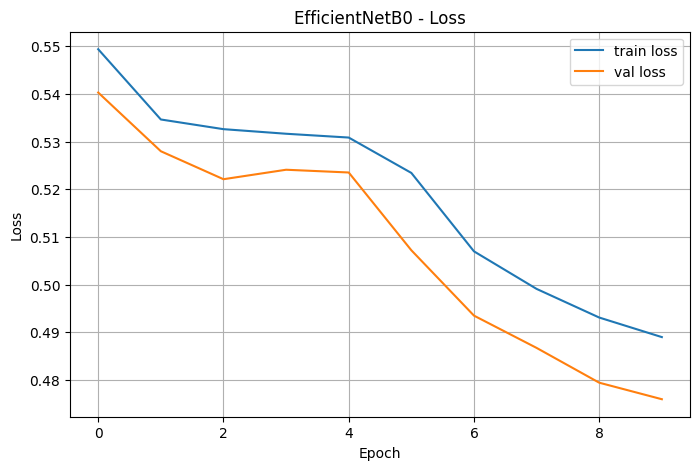

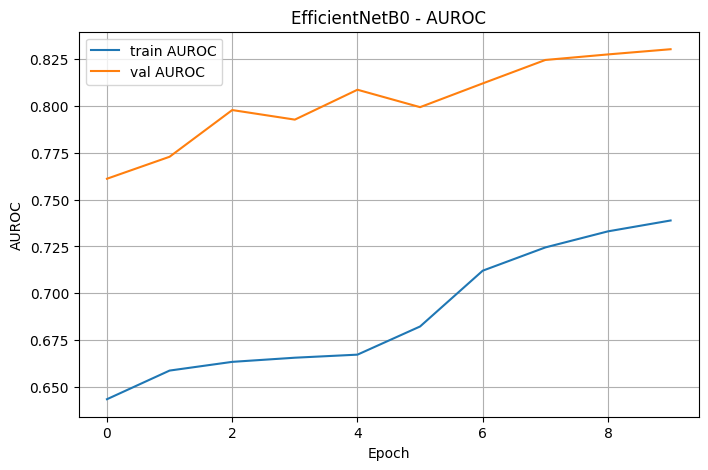

In [64]:
def combine_histories(history1, history2):
    combined = {}
    for key in history1.history.keys():
        combined[key] = history1.history[key] + history2.history.get(key, [])
    return combined

combined_history = combine_histories(history_head, history_finetune)

plt.figure(figsize=(8, 5))
plt.plot(combined_history["loss"], label="train loss")
plt.plot(combined_history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNetB0 - Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(combined_history["auc_roc"], label="train AUROC")
plt.plot(combined_history["val_auc_roc"], label="val AUROC")
plt.xlabel("Epoch")
plt.ylabel("AUROC")
plt.title("EfficientNetB0 - AUROC")
plt.legend()
plt.grid(True)
plt.show()

## Evaluer modellen på valideringssettet

In [65]:
eval_results = model.evaluate(valid_ds, return_dict=True)
eval_results

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - auc_pr: 0.6534 - auc_roc: 0.8301 - binary_accuracy: 0.7713 - loss: 0.4760


{'auc_pr': 0.6534277200698853,
 'auc_roc': 0.8301394581794739,
 'binary_accuracy': 0.771287202835083,
 'loss': 0.4759761691093445}

In [66]:
y_true = []
y_pred = []

for images, labels in valid_ds:
    preds = model.predict(images, verbose=0)
    y_true.append(labels.numpy())
    y_pred.append(preds)

y_true = np.vstack(y_true)
y_pred = np.vstack(y_pred)

print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)

y_true shape: (202, 5)
y_pred shape: (202, 5)


## Beregn per-label AUROC og PR-AUC

In [67]:
per_label_results = []

for i, label in enumerate(LABELS):
    auroc = roc_auc_score(y_true[:, i], y_pred[:, i])
    ap = average_precision_score(y_true[:, i], y_pred[:, i])

    per_label_results.append({
        "label": label,
        "AUROC": auroc,
        "PR_AUC": ap
    })

per_label_df = pd.DataFrame(per_label_results)
per_label_df

,label,AUROC,PR_AUC
0,Atelectasis,0.781627,0.605508
1,Cardiomegaly,0.732175,0.627852
2,Consolidation,0.836581,0.431778
3,Edema,0.901190,0.775429
4,Pleural Effusion,0.897418,0.836298


## Finn beste threshold per label
Vi tester thresholds fra 0.1 til 0.9 og velger den som gir best F1-score per label.

In [68]:
thresholds = np.arange(0.1, 0.91, 0.05)

best_thresholds = {}
threshold_results = []

for i, label in enumerate(LABELS):
    best_f1 = -1
    best_t = 0.5

    for t in thresholds:
        preds_bin = (y_pred[:, i] >= t).astype(int)
        f1 = f1_score(y_true[:, i], preds_bin, zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            best_t = t

    best_thresholds[label] = float(best_t)

    preds_best = (y_pred[:, i] >= best_t).astype(int)
    precision = precision_score(y_true[:, i], preds_best, zero_division=0)
    recall = recall_score(y_true[:, i], preds_best, zero_division=0)
    f1 = f1_score(y_true[:, i], preds_best, zero_division=0)

    threshold_results.append({
        "label": label,
        "best_threshold": best_t,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,label,best_threshold,precision,recall,f1
0,Atelectasis,0.30,0.573913,0.880000,0.694737
1,Cardiomegaly,0.10,0.473118,0.666667,0.553459
2,Consolidation,0.20,0.322581,0.937500,0.480000
3,Edema,0.45,0.688889,0.738095,0.712644
4,Pleural Effusion,0.30,0.584158,0.921875,0.715152


In [69]:
thresholds_path = RESULTS_DIR / "efficientnetb0_best_thresholds.json"

with open(thresholds_path, "w") as f:
    json.dump(best_thresholds, f, indent=2)

print("Saved best thresholds to:", thresholds_path)
print(best_thresholds)

Saved best thresholds to: /content/drive/MyDrive/DAT255_CheXpert_Project/results/efficientnetb0_best_thresholds.json
{'Atelectasis': 0.30000000000000004, 'Cardiomegaly': 0.1, 'Consolidation': 0.20000000000000004, 'Edema': 0.45000000000000007, 'Pleural Effusion': 0.30000000000000004}


## Evaluer med standard threshold = 0.5 og med optimaliserte thresholds

In [70]:
def evaluate_multilabel_at_thresholds(y_true, y_pred, labels, threshold_dict=None, default_threshold=0.5):
    rows = []

    for i, label in enumerate(labels):
        threshold = threshold_dict[label] if threshold_dict is not None else default_threshold
        preds_bin = (y_pred[:, i] >= threshold).astype(int)

        rows.append({
            "label": label,
            "threshold": threshold,
            "precision": precision_score(y_true[:, i], preds_bin, zero_division=0),
            "recall": recall_score(y_true[:, i], preds_bin, zero_division=0),
            "f1": f1_score(y_true[:, i], preds_bin, zero_division=0)
        })

    return pd.DataFrame(rows)

results_default = evaluate_multilabel_at_thresholds(
    y_true, y_pred, LABELS, threshold_dict=None, default_threshold=0.5
)

results_best = evaluate_multilabel_at_thresholds(
    y_true, y_pred, LABELS, threshold_dict=best_thresholds
)

print("Results at threshold = 0.5")
display(results_default)

print("\nResults at best per-label thresholds")
display(results_best)

Results at threshold = 0.5


,label,threshold,precision,recall,f1
0,Atelectasis,0.5,0.500000,0.093333,0.157303
1,Cardiomegaly,0.5,1.000000,0.030303,0.058824
2,Consolidation,0.5,0.000000,0.000000,0.000000
3,Edema,0.5,0.764706,0.619048,0.684211
4,Pleural Effusion,0.5,0.725806,0.703125,0.714286



Results at best per-label thresholds


,label,threshold,precision,recall,f1
0,Atelectasis,0.30,0.573913,0.880000,0.694737
1,Cardiomegaly,0.10,0.473118,0.666667,0.553459
2,Consolidation,0.20,0.322581,0.937500,0.480000
3,Edema,0.45,0.688889,0.738095,0.712644
4,Pleural Effusion,0.30,0.584158,0.921875,0.715152


## Lagre resultater til filer

In [71]:
per_label_csv_path = RESULTS_DIR / "efficientnetb0_per_label_metrics.csv"
threshold_csv_path = RESULTS_DIR / "efficientnetb0_threshold_metrics.csv"
eval_json_path = RESULTS_DIR / "efficientnetb0_eval_results.json"

per_label_df.to_csv(per_label_csv_path, index=False)
threshold_df.to_csv(threshold_csv_path, index=False)

with open(eval_json_path, "w") as f:
    json.dump({k: float(v) for k, v in eval_results.items()}, f, indent=2)

print("Saved:", per_label_csv_path)
print("Saved:", threshold_csv_path)
print("Saved:", eval_json_path)

Saved: /content/drive/MyDrive/DAT255_CheXpert_Project/results/efficientnetb0_per_label_metrics.csv
Saved: /content/drive/MyDrive/DAT255_CheXpert_Project/results/efficientnetb0_threshold_metrics.csv
Saved: /content/drive/MyDrive/DAT255_CheXpert_Project/results/efficientnetb0_eval_results.json


## Sammenlign med tidligere modeller


In [72]:
current_summary = pd.DataFrame([{
    "model": "EfficientNetB0",
    "val_loss": eval_results.get("loss", np.nan),
    "val_binary_accuracy": eval_results.get("binary_accuracy", np.nan),
    "val_auc_roc": eval_results.get("auc_roc", np.nan),
    "val_auc_pr": eval_results.get("auc_pr", np.nan)
}])

current_summary

,model,val_loss,val_binary_accuracy,val_auc_roc,val_auc_pr
0,EfficientNetB0,0.475976,0.771287,0.830139,0.653428


## 26. Samlet sammenligning av alle modeller (automatisk)

Denne cellen leser evalueringsresultater fra:
- baseline CNN
- DenseNet121
- ResNet50
- EfficientNetB0

og lager en samlet tabell basert på valideringsmetrikker.

In [73]:
# --------------------------------------------------
# Filbaner (basert på det du faktisk har i mappen)
# --------------------------------------------------
files = {
    "Baseline CNN": RESULTS_DIR / "baseline_cnn_eval_metrics.json",
    "DenseNet121": RESULTS_DIR / "densenet121_eval_metrics.json",
    "ResNet50": RESULTS_DIR / "resnet50_eval_metrics.json",
    "EfficientNetB0": RESULTS_DIR / "efficientnetb0_eval_results.json",
}

# --------------------------------------------------
# Funksjon for å lese JSON
# --------------------------------------------------
def load_metrics(path):
    if not path.exists():
        print(f"[Missing] {path.name}")
        return None

    with open(path, "r") as f:
        data = json.load(f)

    return {
        "val_loss": float(data.get("loss", np.nan)),
        "val_binary_accuracy": float(data.get("binary_accuracy", np.nan)),
        "val_auc_roc": float(data.get("auc_roc", np.nan)),
        "val_auc_pr": float(data.get("auc_pr", np.nan)),
    }

# --------------------------------------------------
# Bygg sammenligningstabell
# --------------------------------------------------
rows = []

for model_name, path in files.items():
    metrics = load_metrics(path)

    if metrics is None:
        continue

    row = {"model": model_name}
    row.update(metrics)
    rows.append(row)

comparison_df = pd.DataFrame(rows)

# --------------------------------------------------
# Sorter etter beste modell (AUROC)
# --------------------------------------------------
if not comparison_df.empty:
    comparison_df = comparison_df.sort_values(
        by="val_auc_roc",
        ascending=False
    ).reset_index(drop=True)

    print("Model comparison (sorted by AUROC):")
    display(comparison_df)

    # Lagre
    save_path = RESULTS_DIR / "ALL_MODELS_COMPARISON.csv"
    comparison_df.to_csv(save_path, index=False)

    print("\nSaved to:", save_path)

else:
    print("No models found.")


# Original content for pretty display
if not comparison_df.empty:
    pretty_df = comparison_df.copy()

    for col in ["val_loss", "val_binary_accuracy", "val_auc_roc", "val_auc_pr"]:
        if col in pretty_df.columns:
            pretty_df[col] = pretty_df[col].round(4)

    print("\nPretty version (for report):")
    display(pretty_df)


Model comparison (sorted by AUROC):


,model,val_loss,val_binary_accuracy,val_auc_roc,val_auc_pr
0,Baseline CNN,0.443038,0.780198,0.855625,0.684061
1,ResNet50,0.457249,0.792079,0.849505,0.667688
2,DenseNet121,0.469153,0.760396,0.840413,0.653815
3,EfficientNetB0,0.475976,0.771287,0.830139,0.653428



Saved to: /content/drive/MyDrive/DAT255_CheXpert_Project/results/ALL_MODELS_COMPARISON.csv

Pretty version (for report):


,model,val_loss,val_binary_accuracy,val_auc_roc,val_auc_pr
0,Baseline CNN,0.4430,0.7802,0.8556,0.6841
1,ResNet50,0.4572,0.7921,0.8495,0.6677
2,DenseNet121,0.4692,0.7604,0.8404,0.6538
3,EfficientNetB0,0.4760,0.7713,0.8301,0.6534


In [74]:
# --------------------------------------------------
# Filbaner (basert på det du faktisk har i mappen)
# --------------------------------------------------
files = {
    "Baseline CNN": RESULTS_DIR / "baseline_cnn_eval_metrics.json",
    "DenseNet121": RESULTS_DIR / "densenet121_eval_metrics.json",
    "ResNet50": RESULTS_DIR / "resnet50_eval_metrics.json",
    "EfficientNetB0": RESULTS_DIR / "efficientnetb0_eval_results.json",
}

# --------------------------------------------------
# Funksjon for å lese JSON
# --------------------------------------------------
def load_metrics(path):
    if not path.exists():
        print(f"[Missing] {path.name}")
        return None

    with open(path, "r") as f:
        data = json.load(f)

    return {
        "val_loss": float(data.get("loss", np.nan)),
        "val_binary_accuracy": float(data.get("binary_accuracy", np.nan)),
        "val_auc_roc": float(data.get("auc_roc", np.nan)),
        "val_auc_pr": float(data.get("auc_pr", np.nan)),
    }

# --------------------------------------------------
# Bygg sammenligningstabell
# --------------------------------------------------
rows = []

for model_name, path in files.items():
    metrics = load_metrics(path)

    if metrics is None:
        continue

    row = {"model": model_name}
    row.update(metrics)
    rows.append(row)

comparison_df = pd.DataFrame(rows)

# --------------------------------------------------
# Sorter etter beste modell (AUROC)
# --------------------------------------------------
if not comparison_df.empty:
    comparison_df = comparison_df.sort_values(
        by="val_auc_roc",
        ascending=False
    ).reset_index(drop=True)

    print("Model comparison (sorted by AUROC):")
    display(comparison_df)

    # Lagre
    save_path = RESULTS_DIR / "ALL_MODELS_COMPARISON.csv"
    comparison_df.to_csv(save_path, index=False)

    print("\nSaved to:", save_path)

else:
    print("No models found.")

Model comparison (sorted by AUROC):


,model,val_loss,val_binary_accuracy,val_auc_roc,val_auc_pr
0,Baseline CNN,0.443038,0.780198,0.855625,0.684061
1,ResNet50,0.457249,0.792079,0.849505,0.667688
2,DenseNet121,0.469153,0.760396,0.840413,0.653815
3,EfficientNetB0,0.475976,0.771287,0.830139,0.653428



Saved to: /content/drive/MyDrive/DAT255_CheXpert_Project/results/ALL_MODELS_COMPARISON.csv


## Kort konklusjon
Denne notebooken gir en ekstra transfer learning-modell som kan sammenlignes direkte
med baseline CNN, DenseNet121 og ResNet50.